# Algoritmos de Optimización - Trabajo Práctico

**Nombre y Apellidos:** Reda Bennor Haliba

**URL del repositorio:** https://github.com/redaBencworworben/03MIAR---Algoritmos-de-Optimizacion

**Problema seleccionado:**
> **2. Organizar los horarios de partidos de La Liga**

### Descripción del problema

Desde La Liga de fútbol profesional se pretende organizar los horarios de los partidos de liga de cada jornada. Se debe diseñar un algoritmo que realice la asignación de los partidos a los horarios de forma que **maximice la audiencia**.

**Datos del problema:**
- 20 equipos → 10 partidos por jornada
- 10 franjas horarias disponibles
- 3 categorías de equipos: A (3 equipos), B (11 equipos), C (6 equipos)
- Audiencia base según categorías (en millones, referencia: Sábado 20h)
- Coeficientes de ponderación por horario
- Reducción por coincidencia de partidos
- Obligatorio: 1 partido el viernes y 1 el lunes

---
## 1. Carga de datos y modelado

In [1]:
import numpy as np
import pandas as pd
from itertools import permutations
from math import factorial
import random
import math
import time
import matplotlib.pyplot as plt
import copy

# Semilla para reproducibilidad
random.seed(42)
np.random.seed(42)

In [2]:
# ============================================================
# DATOS DEL PROBLEMA
# ============================================================

# --- Categorías de equipos ---
# A: 3 equipos (más seguidores), B: 11 equipos, C: 6 equipos (menos seguidores)
EQUIPOS_A = 3
EQUIPOS_B = 11
EQUIPOS_C = 6
TOTAL_EQUIPOS = EQUIPOS_A + EQUIPOS_B + EQUIPOS_C  # 20
PARTIDOS_POR_JORNADA = TOTAL_EQUIPOS // 2  # 10

# --- Audiencia base (millones) en Sábado 20h (el mejor horario) ---
# Matriz simétrica: audiencia_base[cat_local][cat_visitante]
CATEGORIAS = ['A', 'B', 'C']
AUDIENCIA_BASE = {
    ('A', 'A'): 2.0,
    ('A', 'B'): 1.3, ('B', 'A'): 1.3,
    ('A', 'C'): 1.0, ('C', 'A'): 1.0,
    ('B', 'B'): 0.9,
    ('B', 'C'): 0.75, ('C', 'B'): 0.75,
    ('C', 'C'): 0.47,
}

# --- Franjas horarias disponibles ---
# Formato: (día, hora) -> código
HORARIOS = [
    ('Viernes', '20h'),   # V20 - índice 0
    ('Sábado',  '12h'),   # S12 - índice 1
    ('Sábado',  '16h'),   # S16 - índice 2
    ('Sábado',  '18h'),   # S18 - índice 3
    ('Sábado',  '20h'),   # S20 - índice 4
    ('Domingo', '12h'),   # D12 - índice 5
    ('Domingo', '16h'),   # D16 - índice 6
    ('Domingo', '18h'),   # D18 - índice 7
    ('Domingo', '20h'),   # D20 - índice 8
    ('Lunes',   '20h'),   # L20 - índice 9
]
NOMBRES_HORARIOS = [f"{d[0]}{d[1][:2]}" for d in HORARIOS]  # V20, S12, ...
NUM_HORARIOS = len(HORARIOS)  # 10

# --- Coeficiente de ponderación por horario ---
# Reduce la audiencia base según día y hora (1.0 = máximo = Sábado 20h)
PONDERACION = {
    ('Viernes', '20h'): 0.40,
    ('Sábado',  '12h'): 0.55,
    ('Sábado',  '16h'): 0.70,
    ('Sábado',  '18h'): 0.80,
    ('Sábado',  '20h'): 1.00,
    ('Domingo', '12h'): 0.45,
    ('Domingo', '16h'): 0.75,
    ('Domingo', '18h'): 0.85,
    ('Domingo', '20h'): 1.00,
    ('Lunes',   '20h'): 0.40,
}

# Vector de ponderación en orden de HORARIOS
POND_VECTOR = [PONDERACION[h] for h in HORARIOS]

# --- Tabla de reducción por coincidencia ---
# coincidencias = número de OTROS partidos al mismo tiempo
# El factor es (1 - porcentaje_reduccion)
REDUCCION_COINCIDENCIA = {
    0: 1.00,   # Solo: sin reducción
    1: 0.75,   # 2 partidos a la vez: -25%
    2: 0.55,   # 3 partidos a la vez: -45%
    3: 0.40,   # 4 partidos: -60%
    4: 0.30,   # 5 partidos: -70%
    5: 0.25,   # 6 partidos: -75%
    6: 0.22,   # 7 partidos: -78%
    7: 0.20,   # 8 partidos: -80%
    8: 0.20,   # 9 partidos: -80%
}

print("Datos cargados correctamente.")
print(f"Equipos: {TOTAL_EQUIPOS} (A:{EQUIPOS_A}, B:{EQUIPOS_B}, C:{EQUIPOS_C})")
print(f"Partidos por jornada: {PARTIDOS_POR_JORNADA}")
print(f"Franjas horarias: {NUM_HORARIOS}")
print(f"\nHorarios: {NOMBRES_HORARIOS}")
print(f"Ponderaciones: {POND_VECTOR}")

Datos cargados correctamente.
Equipos: 20 (A:3, B:11, C:6)
Partidos por jornada: 10
Franjas horarias: 10

Horarios: ['Viernes20', 'Sábado12', 'Sábado16', 'Sábado18', 'Sábado20', 'Domingo12', 'Domingo16', 'Domingo18', 'Domingo20', 'Lunes20']
Ponderaciones: [0.4, 0.55, 0.7, 0.8, 1.0, 0.45, 0.75, 0.85, 1.0, 0.4]


In [3]:
# Mostrar tablas de datos de forma legible
print("=== Audiencia base (millones, referencia Sábado 20h) ===")
df_aud = pd.DataFrame(
    [[AUDIENCIA_BASE.get((i, j), '-') for j in CATEGORIAS] for i in CATEGORIAS],
    index=CATEGORIAS, columns=CATEGORIAS
)
print(df_aud.to_string())

print("\n=== Coeficientes de ponderación por horario ===")
df_pond = pd.DataFrame(
    {'Horario': NOMBRES_HORARIOS, 'Coeficiente': POND_VECTOR}
)
print(df_pond.to_string(index=False))

print("\n=== Reducción por coincidencia ===")
df_coinc = pd.DataFrame([
    {'Coincidencias': k, 'Reducción': f"{int((1-v)*100)}%", 'Factor': v}
    for k, v in REDUCCION_COINCIDENCIA.items()
])
print(df_coinc.to_string(index=False))

=== Audiencia base (millones, referencia Sábado 20h) ===
     A     B     C
A  2.0  1.30  1.00
B  1.3  0.90  0.75
C  1.0  0.75  0.47

=== Coeficientes de ponderación por horario ===
  Horario  Coeficiente
Viernes20         0.40
 Sábado12         0.55
 Sábado16         0.70
 Sábado18         0.80
 Sábado20         1.00
Domingo12         0.45
Domingo16         0.75
Domingo18         0.85
Domingo20         1.00
  Lunes20         0.40

=== Reducción por coincidencia ===
 Coincidencias Reducción  Factor
             0        0%    1.00
             1       25%    0.75
             2       44%    0.55
             3       60%    0.40
             4       70%    0.30
             5       75%    0.25
             6       78%    0.22
             7       80%    0.20
             8       80%    0.20


---
## 2. Análisis del espacio de soluciones

### (\*) ¿Cuántas posibilidades hay sin tener en cuenta las restricciones?

Sin restricciones, tenemos 10 partidos y 10 franjas horarias. Si cada partido puede ir a cualquier franja (permitiendo múltiples partidos por franja), el número de asignaciones posibles es:

$$10^{10} = 10.000.000.000$$

Si asignamos exactamente un partido por franja (biyección), las posibilidades son:

$$10! = 3.628.800$$

### (\*) ¿Cuántas posibilidades hay teniendo en cuenta todas las restricciones?

Con la restricción de que se permite la coincidencia de horarios (varios partidos en la misma franja), pero **obligatoriamente** debe haber exactamente 1 partido el viernes y 1 el lunes, tenemos:

- Elegir 1 de 10 partidos para el viernes: $C(10,1) = 10$
- Elegir 1 de 9 restantes para el lunes: $C(9,1) = 9$
- Los 8 partidos restantes se reparten entre 8 franjas de sábado/domingo, pudiendo coincidir: $8^8 = 16.777.216$
- **Total: $10 \times 9 \times 8^8 = 1.509.949.440$**

Si se asigna exactamente 1 partido por franja (sin coincidencias):
- **Total: $10 \times 9 \times 8! = 3.628.800$** (que es simplemente $10!$)

Ambos escenarios son explorables computacionalmente (millones, no billones). La fuerza bruta es **viable** para este problema.

In [4]:
# Cálculo numérico del espacio de soluciones
sin_restricciones = 10**10
print(f"Sin restricciones (cualquier asignación): 10^10 = {sin_restricciones:,}")

biyeccion = factorial(10)
print(f"Biyección (1 partido por franja): 10! = {biyeccion:,}")

con_coincidencia = 10 * 9 * (8**8)
print(f"Con restricciones (V+L obligatorios, coincidencia libre): {con_coincidencia:,}")

sin_coincidencia = 10 * 9 * factorial(8)
print(f"Con restricciones (sin coincidencia): {sin_coincidencia:,}")

print(f"\nNota: 10! = {biyeccion:,} es abordable por fuerza bruta.")

Sin restricciones (cualquier asignación): 10^10 = 10,000,000,000
Biyección (1 partido por franja): 10! = 3,628,800
Con restricciones (V+L obligatorios, coincidencia libre): 1,509,949,440
Con restricciones (sin coincidencia): 3,628,800

Nota: 10! = 3,628,800 es abordable por fuerza bruta.


---
## 3. Modelo para el espacio de soluciones

### (\*) ¿Cuál es la estructura de datos que mejor se adapta al problema?

La estructura elegida es un **vector de asignación** (lista) donde el índice $i$ representa el partido $i$ y el valor es el índice de la franja horaria asignada.

```python
asignacion = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
# Partido 0 -> Viernes 20h (franja 0)
# Partido 1 -> Sábado 12h (franja 1)
# ...
```

**Argumentación:**
- Cada partido tiene exactamente una franja asignada
- Una permutación de [0..9] representa una asignación sin coincidencias
- Fácil de generar con `itertools.permutations`
- Calcular coincidencias: contar cuántos partidos comparten la misma franja
- Cada partido se modela como una tupla `(categoria_local, categoria_visitante)`

---
## 4. Función objetivo

### (\*) ¿Cuál es la función objetivo?

La función objetivo es la **audiencia total** de la jornada:

$$f(S) = \sum_{i=1}^{10} \text{audiencia\_base}(p_i) \times \text{ponderaci\acute{o}n}(h_i) \times \text{coincidencia}(h_i)$$

Donde:
- $p_i$ es el partido $i$ con sus categorías de equipos
- $h_i$ es la franja horaria asignada al partido $i$
- $\text{audiencia\_base}(p_i)$ depende de las categorías de los equipos
- $\text{ponderaci\acute{o}n}(h_i)$ es el coeficiente del horario
- $\text{coincidencia}(h_i)$ es el factor de reducción según cuántos otros partidos coinciden en el mismo horario

### (\*) ¿Es un problema de maximización o minimización?

Es un **problema de maximización**. Queremos maximizar la audiencia total.

In [5]:
def generar_jornada_ejemplo():
    """
    Genera la jornada de ejemplo del enunciado para verificar los cálculos.
    Cada partido es (cat_local, cat_visitante, nombre_descriptivo).
    """
    partidos = [
        ('B', 'A', 'Celta - Real Madrid'),
        ('B', 'A', 'Valencia - R. Sociedad'),
        ('C', 'C', 'Mallorca - Eibar'),
        ('B', 'A', 'Athletic - Barcelona'),
        ('C', 'C', 'Leganés - Osasuna'),
        ('B', 'C', 'Villarreal - Granada'),
        ('B', 'B', 'Alavés - Levante'),
        ('B', 'B', 'Espanyol - Sevilla'),
        ('B', 'C', 'Betis - Valladolid'),
        ('B', 'B', 'Atlético - Getafe'),
    ]
    return partidos


def calcular_audiencia(partidos, asignacion):
    """
    Calcula la audiencia total de una jornada dada una asignación de partidos a horarios.
    
    Args:
        partidos: lista de tuplas (cat_local, cat_visitante, nombre)
        asignacion: lista de índices de franja horaria para cada partido
    
    Returns:
        (audiencia_total, detalle_por_partido)
    """
    n = len(partidos)
    
    # Contar coincidencias por horario
    conteo_horario = {}
    for h in asignacion:
        conteo_horario[h] = conteo_horario.get(h, 0) + 1
    
    audiencia_total = 0.0
    detalle = []
    
    for i in range(n):
        cat_l, cat_v = partidos[i][0], partidos[i][1]
        horario_idx = asignacion[i]
        horario = HORARIOS[horario_idx]
        
        # Audiencia base según categorías
        base = AUDIENCIA_BASE[(cat_l, cat_v)]
        
        # Ponderación por horario
        pond = PONDERACION[horario]
        
        # Factor de coincidencia
        coincidencias = conteo_horario[horario_idx] - 1  # Otros partidos al mismo tiempo
        factor_coinc = REDUCCION_COINCIDENCIA.get(coincidencias, 0.20)
        
        # Audiencia del partido
        aud_partido = base * pond * factor_coinc
        audiencia_total += aud_partido
        
        detalle.append({
            'partido': partidos[i][2] if len(partidos[i]) > 2 else f"{cat_l}-{cat_v}",
            'categorias': f"{cat_l}-{cat_v}",
            'horario': NOMBRES_HORARIOS[horario_idx],
            'base': base,
            'ponderacion': pond,
            'base_x_pond': round(base * pond, 2),
            'coincidencias': coincidencias,
            'factor_coinc': factor_coinc,
            'audiencia': round(aud_partido, 2)
        })
    
    return round(audiencia_total, 2), detalle


def calcular_audiencia_rapida(partidos, asignacion):
    """
    Versión rápida que solo devuelve la audiencia total (para optimización).
    """
    conteo_horario = {}
    for h in asignacion:
        conteo_horario[h] = conteo_horario.get(h, 0) + 1
    
    total = 0.0
    for i in range(len(partidos)):
        base = AUDIENCIA_BASE[(partidos[i][0], partidos[i][1])]
        pond = POND_VECTOR[asignacion[i]]
        coinc = conteo_horario[asignacion[i]] - 1
        factor = REDUCCION_COINCIDENCIA.get(coinc, 0.20)
        total += base * pond * factor
    
    return total

In [6]:
# Verificar con el ejemplo del enunciado (página 7 del PDF)
partidos_ejemplo = generar_jornada_ejemplo()

# Asignación del ejemplo: V20, S12, S16, S18, S20, D16, D16, D18, D20, L20
asignacion_ejemplo = [0, 1, 2, 3, 4, 6, 6, 7, 8, 9]

aud_total, detalle = calcular_audiencia(partidos_ejemplo, asignacion_ejemplo)

print("Verificación con el ejemplo del enunciado:")
print("=" * 100)
df_detalle = pd.DataFrame(detalle)
print(df_detalle.to_string(index=False))
print(f"\nAudiencia total: {aud_total} millones")
print(f"(Valor esperado del enunciado: 5.88 millones)")

Verificación con el ejemplo del enunciado:
               partido categorias   horario  base  ponderacion  base_x_pond  coincidencias  factor_coinc  audiencia
   Celta - Real Madrid        B-A Viernes20  1.30         0.40         0.52              0          1.00       0.52
Valencia - R. Sociedad        B-A  Sábado12  1.30         0.55         0.72              0          1.00       0.72
      Mallorca - Eibar        C-C  Sábado16  0.47         0.70         0.33              0          1.00       0.33
  Athletic - Barcelona        B-A  Sábado18  1.30         0.80         1.04              0          1.00       1.04
     Leganés - Osasuna        C-C  Sábado20  0.47         1.00         0.47              0          1.00       0.47
  Villarreal - Granada        B-C Domingo16  0.75         0.75         0.56              1          0.75       0.42
      Alavés - Levante        B-B Domingo16  0.90         0.75         0.68              1          0.75       0.51
    Espanyol - Sevilla       

---
## 5. Algoritmo por fuerza bruta

### Diseño del algoritmo

Dado que el espacio de soluciones es $10! = 3.628.800$ (asignando un partido por franja sin coincidencias), podemos explorar **todas** las permutaciones y encontrar la óptima.

También implementamos una versión con coincidencias permitidas (más compleja).

In [7]:
def fuerza_bruta_sin_coincidencia(partidos):
    """
    Fuerza bruta: prueba todas las permutaciones (10! = 3.628.800)
    asignando exactamente 1 partido por franja horaria.
    
    Args:
        partidos: lista de tuplas (cat_local, cat_visitante, nombre)
    
    Returns:
        (mejor_asignacion, mejor_audiencia, total_evaluadas)
    """
    mejor_asignacion = None
    mejor_audiencia = -1
    total = 0
    
    # Generar todas las permutaciones de 10 franjas
    for perm in permutations(range(10)):
        asignacion = list(perm)
        
        # Verificar restricción: franja 0 (V20) y franja 9 (L20) deben tener partido
        # En una permutación completa, todas las franjas tienen exactamente 1 partido,
        # por lo que esta restricción se cumple automáticamente.
        
        aud = calcular_audiencia_rapida(partidos, asignacion)
        total += 1
        
        if aud > mejor_audiencia:
            mejor_audiencia = aud
            mejor_asignacion = asignacion
    
    return mejor_asignacion, round(mejor_audiencia, 4), total


# Ejecutar fuerza bruta
print("Ejecutando fuerza bruta (10! = 3.628.800 permutaciones)...")
inicio = time.time()
mejor_fb, aud_fb, total_fb = fuerza_bruta_sin_coincidencia(partidos_ejemplo)
tiempo_fb = time.time() - inicio

print(f"Tiempo: {tiempo_fb:.2f} segundos")
print(f"Permutaciones evaluadas: {total_fb:,}")
print(f"Mejor audiencia: {aud_fb:.2f} millones")
print(f"\nMejor asignación:")
_, detalle_fb = calcular_audiencia(partidos_ejemplo, mejor_fb)
df_fb = pd.DataFrame(detalle_fb)
print(df_fb.to_string(index=False))

Ejecutando fuerza bruta (10! = 3.628.800 permutaciones)...


Tiempo: 57.04 segundos
Permutaciones evaluadas: 3,628,800
Mejor audiencia: 6.86 millones

Mejor asignación:
               partido categorias   horario  base  ponderacion  base_x_pond  coincidencias  factor_coinc  audiencia
   Celta - Real Madrid        B-A  Sábado20  1.30         1.00         1.30              0           1.0       1.30
Valencia - R. Sociedad        B-A Domingo18  1.30         0.85         1.10              0           1.0       1.10
      Mallorca - Eibar        C-C Viernes20  0.47         0.40         0.19              0           1.0       0.19
  Athletic - Barcelona        B-A Domingo20  1.30         1.00         1.30              0           1.0       1.30
     Leganés - Osasuna        C-C   Lunes20  0.47         0.40         0.19              0           1.0       0.19
  Villarreal - Granada        B-C  Sábado12  0.75         0.55         0.41              0           1.0       0.41
      Alavés - Levante        B-B  Sábado16  0.90         0.70         0.63     

### Complejidad del algoritmo por fuerza bruta

- **Sin coincidencias**: Se generan $n!$ permutaciones, y cada una se evalúa en $O(n)$
  - **Complejidad: $O(n! \cdot n)$** donde $n = 10$
  - Total: $10! \times 10 = 36.288.000$ operaciones
  - Viable en pocos segundos

- **Con coincidencias**: El espacio crece a $n^n$ asignaciones posibles
  - **Complejidad: $O(n^n \cdot n)$**
  - Total: $10^{10} \times 10 = 100.000.000.000$ → inviable

La fuerza bruta sin coincidencias es factible y nos da la **solución óptima global** para ese escenario.

---
## 6. Algoritmos mejorados

### (\*) Diseño de algoritmos que mejoran la fuerza bruta

Aunque la fuerza bruta es viable para $n=10$, implementamos algoritmos más eficientes que escalarían a problemas mayores:

1. **Algoritmo Voraz (Greedy)**: Asigna los partidos de mayor audiencia base a los mejores horarios
2. **Recocido Simulado**: Explora el espacio con movimientos aleatorios y aceptación probabilística

Estos mejoran la fuerza bruta porque:
- El voraz tiene complejidad $O(n^2)$ frente a $O(n!)$
- El recocido simulado tiene complejidad $O(L \cdot I \cdot n)$, controlable por parámetros

### 6.1 Algoritmo Voraz (Greedy)

In [8]:
def algoritmo_voraz(partidos):
    """
    Algoritmo voraz: asigna los partidos con mayor audiencia base
    a las franjas con mejor ponderación.
    
    Estrategia: ordenar partidos por audiencia base (desc) y
    franjas por ponderación (desc), asignar en orden.
    Esto maximiza localmente la contribución de cada partido.
    
    Args:
        partidos: lista de tuplas (cat_local, cat_visitante, nombre)
    
    Returns:
        (asignacion, audiencia)
    """
    n = len(partidos)
    
    # Calcular audiencia base de cada partido
    bases = [(i, AUDIENCIA_BASE[(p[0], p[1])]) for i, p in enumerate(partidos)]
    
    # Ordenar partidos por audiencia base descendente
    bases_ordenadas = sorted(bases, key=lambda x: -x[1])
    
    # Ordenar franjas por ponderación descendente
    franjas_ordenadas = sorted(range(n), key=lambda h: -POND_VECTOR[h])
    
    # Asignar: mejor partido -> mejor franja disponible
    asignacion = [0] * n
    franjas_usadas = set()
    
    for partido_idx, base in bases_ordenadas:
        for franja in franjas_ordenadas:
            if franja not in franjas_usadas:
                asignacion[partido_idx] = franja
                franjas_usadas.add(franja)
                break
    
    aud = calcular_audiencia_rapida(partidos, asignacion)
    return asignacion, round(aud, 4)


# Ejecutar voraz
print("Ejecutando algoritmo voraz...")
inicio = time.time()
asig_voraz, aud_voraz = algoritmo_voraz(partidos_ejemplo)
tiempo_voraz = time.time() - inicio

print(f"Tiempo: {tiempo_voraz:.6f} segundos")
print(f"Audiencia: {aud_voraz:.2f} millones")
print(f"\nAsignación voraz:")
_, detalle_voraz = calcular_audiencia(partidos_ejemplo, asig_voraz)
df_voraz = pd.DataFrame(detalle_voraz)
print(df_voraz.to_string(index=False))

Ejecutando algoritmo voraz...
Tiempo: 0.000344 segundos
Audiencia: 6.86 millones

Asignación voraz:
               partido categorias   horario  base  ponderacion  base_x_pond  coincidencias  factor_coinc  audiencia
   Celta - Real Madrid        B-A  Sábado20  1.30         1.00         1.30              0           1.0       1.30
Valencia - R. Sociedad        B-A Domingo20  1.30         1.00         1.30              0           1.0       1.30
      Mallorca - Eibar        C-C Viernes20  0.47         0.40         0.19              0           1.0       0.19
  Athletic - Barcelona        B-A Domingo18  1.30         0.85         1.10              0           1.0       1.10
     Leganés - Osasuna        C-C   Lunes20  0.47         0.40         0.19              0           1.0       0.19
  Villarreal - Granada        B-C  Sábado12  0.75         0.55         0.41              0           1.0       0.41
      Alavés - Levante        B-B  Sábado18  0.90         0.80         0.72             

### 6.2 Recocido Simulado (Simulated Annealing)

In [9]:
def recocido_simulado_liga(partidos, temp_inicial=50, temp_final=0.01,
                            factor_enfriamiento=0.995, iteraciones_por_temp=100):
    """
    Recocido simulado para maximizar audiencia de La Liga.
    
    Genera vecinos intercambiando las franjas de dos partidos.
    Acepta soluciones peores con probabilidad decreciente.
    
    Args:
        partidos: lista de partidos
        temp_inicial, temp_final, factor_enfriamiento: parámetros de temperatura
        iteraciones_por_temp: iteraciones por nivel de temperatura
    
    Returns:
        (mejor_asignacion, mejor_audiencia, historial)
    """
    n = len(partidos)
    
    # Solución inicial: permutación aleatoria
    actual = list(range(n))
    random.shuffle(actual)
    aud_actual = calcular_audiencia_rapida(partidos, actual)
    
    mejor = list(actual)
    mejor_aud = aud_actual
    historial = [aud_actual]
    
    temp = temp_inicial
    
    while temp > temp_final:
        for _ in range(iteraciones_por_temp):
            # Generar vecino: intercambiar franjas de 2 partidos
            vecino = list(actual)
            i, j = random.sample(range(n), 2)
            vecino[i], vecino[j] = vecino[j], vecino[i]
            
            aud_vecino = calcular_audiencia_rapida(partidos, vecino)
            delta = aud_vecino - aud_actual  # Positivo = mejora (maximizamos)
            
            # Aceptar si mejora, o con probabilidad e^(delta/T) si empeora
            if delta > 0 or random.random() < math.exp(delta / temp):
                actual = vecino
                aud_actual = aud_vecino
                
                if aud_actual > mejor_aud:
                    mejor = list(actual)
                    mejor_aud = aud_actual
            
            historial.append(aud_actual)
        
        temp *= factor_enfriamiento
    
    return mejor, round(mejor_aud, 4), historial


# Ejecutar recocido simulado (5 repeticiones)
print("Ejecutando recocido simulado (5 repeticiones)...\n")
mejor_sa_asig = None
mejor_sa_aud = -1
mejor_historial = None

inicio_total = time.time()
for rep in range(5):
    random.seed(rep * 42)
    asig, aud, hist = recocido_simulado_liga(
        partidos_ejemplo,
        temp_inicial=50, temp_final=0.01,
        factor_enfriamiento=0.995, iteraciones_por_temp=200
    )
    print(f"  Rep {rep+1}: audiencia = {aud:.2f} millones")
    if aud > mejor_sa_aud:
        mejor_sa_aud = aud
        mejor_sa_asig = asig
        mejor_historial = hist

tiempo_sa = time.time() - inicio_total
print(f"\nTiempo total: {tiempo_sa:.2f} segundos")
print(f"Mejor audiencia SA: {mejor_sa_aud:.2f} millones")
print(f"\nMejor asignación SA:")
_, detalle_sa = calcular_audiencia(partidos_ejemplo, mejor_sa_asig)
df_sa = pd.DataFrame(detalle_sa)
print(df_sa.to_string(index=False))

Ejecutando recocido simulado (5 repeticiones)...



  Rep 1: audiencia = 6.86 millones


  Rep 2: audiencia = 6.86 millones


  Rep 3: audiencia = 6.86 millones


  Rep 4: audiencia = 6.86 millones


  Rep 5: audiencia = 6.86 millones

Tiempo total: 45.11 segundos
Mejor audiencia SA: 6.86 millones

Mejor asignación SA:
               partido categorias   horario  base  ponderacion  base_x_pond  coincidencias  factor_coinc  audiencia
   Celta - Real Madrid        B-A Domingo20  1.30         1.00         1.30              0           1.0       1.30
Valencia - R. Sociedad        B-A  Sábado20  1.30         1.00         1.30              0           1.0       1.30
      Mallorca - Eibar        C-C   Lunes20  0.47         0.40         0.19              0           1.0       0.19
  Athletic - Barcelona        B-A Domingo18  1.30         0.85         1.10              0           1.0       1.10
     Leganés - Osasuna        C-C Viernes20  0.47         0.40         0.19              0           1.0       0.19
  Villarreal - Granada        B-C Domingo12  0.75         0.45         0.34              0           1.0       0.34
      Alavés - Levante        B-B  Sábado18  0.90         0.80     

### (\*) Complejidad de los algoritmos mejorados

**Algoritmo Voraz:**
- Ordenar partidos: $O(n \log n)$
- Ordenar franjas: $O(n \log n)$
- Asignación: $O(n^2)$ (para cada partido, buscar franja disponible)
- **Complejidad total: $O(n^2)$**

**Recocido Simulado:**
- Niveles de temperatura: $L = \log(T_{min}/T_{max}) / \log(\alpha)$
- Iteraciones por nivel: $I$
- Evaluar vecino: $O(n)$
- **Complejidad total: $O(L \cdot I \cdot n)$**

| Algoritmo | Complejidad | Calidad |
|-----------|------------|--------|
| Fuerza bruta | $O(n! \cdot n)$ | Óptima (exacta) |
| Voraz | $O(n^2)$ | Buena (no óptima) |
| Recocido Simulado | $O(L \cdot I \cdot n)$ | Cercana al óptimo |

---
## 7. Visualización y comparación de resultados

In [10]:
# Audiencia del ejemplo original
aud_ejemplo = calcular_audiencia_rapida(partidos_ejemplo, asignacion_ejemplo)

# Comparación
print("=" * 65)
print("COMPARACIÓN DE ALGORITMOS")
print("=" * 65)
print(f"{'Algoritmo':<30} {'Audiencia (M)':<15} {'Tiempo (s)':<12}")
print("-" * 65)
print(f"{'Ejemplo del enunciado':<30} {aud_ejemplo:<15.2f} {'-':<12}")
print(f"{'Voraz (Greedy)':<30} {aud_voraz:<15.2f} {tiempo_voraz:<12.6f}")
print(f"{'Recocido Simulado (mejor)':<30} {mejor_sa_aud:<15.2f} {tiempo_sa:<12.2f}")
print(f"{'Fuerza bruta (óptimo)':<30} {aud_fb:<15.2f} {tiempo_fb:<12.2f}")
print("=" * 65)
print(f"\nMejora sobre el ejemplo: {((aud_fb - aud_ejemplo) / aud_ejemplo * 100):.1f}%")

COMPARACIÓN DE ALGORITMOS
Algoritmo                      Audiencia (M)   Tiempo (s)  
-----------------------------------------------------------------
Ejemplo del enunciado          5.88            -           
Voraz (Greedy)                 6.86            0.000344    
Recocido Simulado (mejor)      6.86            45.11       
Fuerza bruta (óptimo)          6.86            57.04       

Mejora sobre el ejemplo: 16.7%


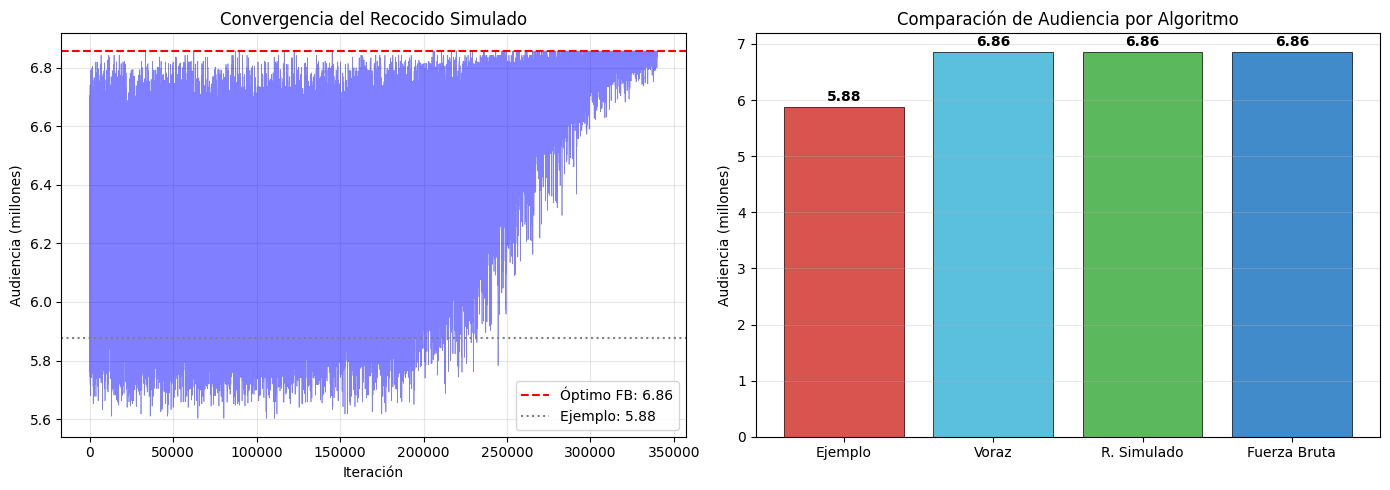

In [11]:
# Gráficos de comparación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Convergencia del recocido simulado
axes[0].plot(mejor_historial, alpha=0.5, linewidth=0.5, color='blue')
axes[0].axhline(y=aud_fb, color='red', linestyle='--', label=f'Óptimo FB: {aud_fb:.2f}')
axes[0].axhline(y=aud_ejemplo, color='gray', linestyle=':', label=f'Ejemplo: {aud_ejemplo:.2f}')
axes[0].set_xlabel('Iteración')
axes[0].set_ylabel('Audiencia (millones)')
axes[0].set_title('Convergencia del Recocido Simulado')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Comparación de audiencias
nombres_alg = ['Ejemplo', 'Voraz', 'R. Simulado', 'Fuerza Bruta']
audiencias = [aud_ejemplo, aud_voraz, mejor_sa_aud, aud_fb]
colores = ['#d9534f', '#5bc0de', '#5cb85c', '#428bca']

bars = axes[1].bar(nombres_alg, audiencias, color=colores, edgecolor='black', linewidth=0.5)
for bar, aud in zip(bars, audiencias):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
                f'{aud:.2f}', ha='center', va='bottom', fontweight='bold')
axes[1].set_ylabel('Audiencia (millones)')
axes[1].set_title('Comparación de Audiencia por Algoritmo')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

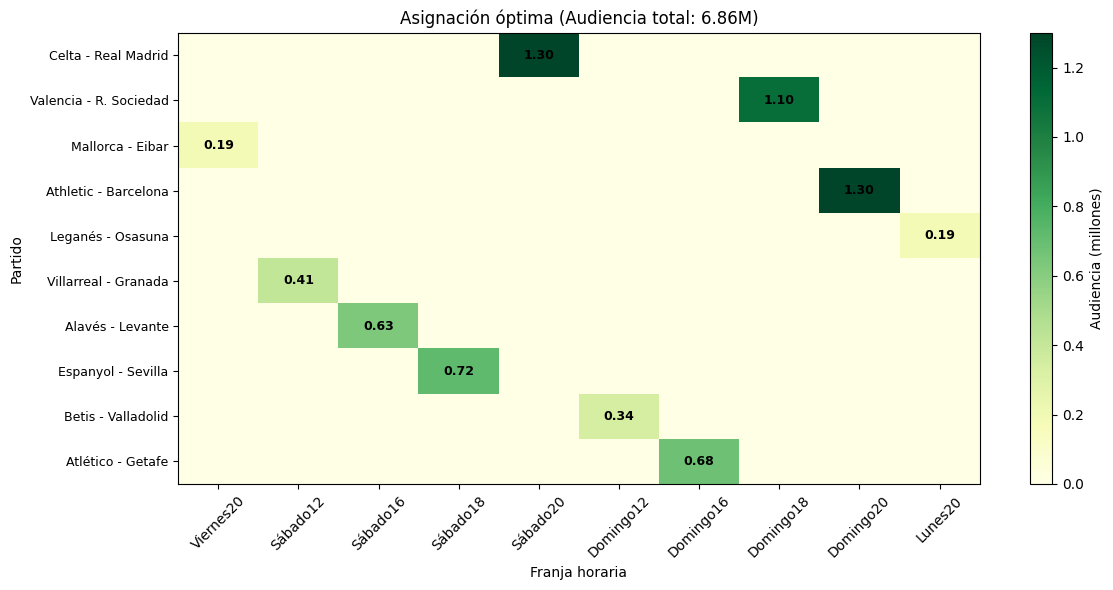

In [12]:
# Visualización de la solución óptima: mapa de calor partidos x horarios
fig, ax = plt.subplots(figsize=(12, 6))

# Crear matriz de asignación: partidos x horarios
n = len(partidos_ejemplo)
heatmap = np.zeros((n, NUM_HORARIOS))

_, detalle_opt = calcular_audiencia(partidos_ejemplo, mejor_fb)
for i, d in enumerate(detalle_opt):
    h_idx = mejor_fb[i]
    heatmap[i, h_idx] = d['audiencia']

im = ax.imshow(heatmap, cmap='YlGn', aspect='auto')
ax.set_xlabel('Franja horaria')
ax.set_ylabel('Partido')
ax.set_xticks(range(NUM_HORARIOS))
ax.set_xticklabels(NOMBRES_HORARIOS, rotation=45)
ax.set_yticks(range(n))
ax.set_yticklabels([p[2] for p in partidos_ejemplo], fontsize=9)
ax.set_title(f'Asignación óptima (Audiencia total: {aud_fb:.2f}M)')

# Añadir texto en celdas con valor
for i in range(n):
    for j in range(NUM_HORARIOS):
        val = heatmap[i, j]
        if val > 0:
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                   color='black', fontweight='bold', fontsize=9)

plt.colorbar(im, ax=ax, label='Audiencia (millones)')
plt.tight_layout()
plt.show()

---
## 8. Juego de datos aleatorio

Generamos jornadas aleatorias con diferentes composiciones de partidos.

In [13]:
def generar_jornada_aleatoria(seed=42):
    """
    Genera una jornada aleatoria de 10 partidos.
    Distribuye los 20 equipos (3A, 11B, 6C) en 10 partidos aleatorios.
    """
    random.seed(seed)
    
    # Crear lista de equipos por categoría
    equipos = ['A'] * EQUIPOS_A + ['B'] * EQUIPOS_B + ['C'] * EQUIPOS_C
    random.shuffle(equipos)
    
    # Emparejar consecutivamente
    partidos = []
    for i in range(0, len(equipos), 2):
        cat_l, cat_v = equipos[i], equipos[i + 1]
        partidos.append((cat_l, cat_v, f"Equipo{i//2*2+1}({cat_l}) - Equipo{i//2*2+2}({cat_v})"))
    
    return partidos


# Generar 5 jornadas aleatorias y aplicar todos los algoritmos
resultados_aleatorios = []

print("Aplicando algoritmos a 5 jornadas aleatorias...\n")

for j in range(5):
    partidos_j = generar_jornada_aleatoria(seed=j * 17 + 7)
    
    # Composición de la jornada
    cats = [f"{p[0]}-{p[1]}" for p in partidos_j]
    
    # Voraz
    _, aud_v = algoritmo_voraz(partidos_j)
    
    # Recocido simulado (3 repeticiones)
    mejor_sa = -1
    for r in range(3):
        random.seed(r * 100 + j)
        _, aud_s, _ = recocido_simulado_liga(
            partidos_j, temp_inicial=50, temp_final=0.01,
            factor_enfriamiento=0.995, iteraciones_por_temp=150
        )
        mejor_sa = max(mejor_sa, aud_s)
    
    # Fuerza bruta
    _, aud_fb_j, _ = fuerza_bruta_sin_coincidencia(partidos_j)
    
    print(f"Jornada {j+1}: Cats={cats}")
    print(f"  Voraz={aud_v:.2f}  SA={mejor_sa:.2f}  FB={aud_fb_j:.2f}")
    
    resultados_aleatorios.append({
        'jornada': f'J{j+1}',
        'voraz': aud_v,
        'recocido_simulado': mejor_sa,
        'fuerza_bruta': aud_fb_j
    })

Aplicando algoritmos a 5 jornadas aleatorias...



Jornada 1: Cats=['C-C', 'B-C', 'B-B', 'C-B', 'C-A', 'B-B', 'C-B', 'B-A', 'A-B', 'B-B']
  Voraz=6.71  SA=6.71  FB=6.71


Jornada 2: Cats=['B-C', 'B-B', 'B-C', 'C-A', 'B-B', 'A-C', 'B-A', 'B-C', 'B-B', 'C-B']
  Voraz=6.53  SA=6.53  FB=6.53


Jornada 3: Cats=['A-C', 'C-A', 'C-B', 'C-B', 'A-B', 'C-B', 'B-B', 'B-C', 'B-B', 'B-B']
  Voraz=6.53  SA=6.53  FB=6.53


Jornada 4: Cats=['B-C', 'C-B', 'A-B', 'A-B', 'B-B', 'B-B', 'C-B', 'B-A', 'C-C', 'B-C']
  Voraz=6.86  SA=6.86  FB=6.86


Jornada 5: Cats=['B-B', 'B-B', 'A-A', 'C-C', 'B-B', 'C-B', 'B-B', 'B-A', 'C-B', 'C-C']
  Voraz=7.22  SA=7.22  FB=7.22


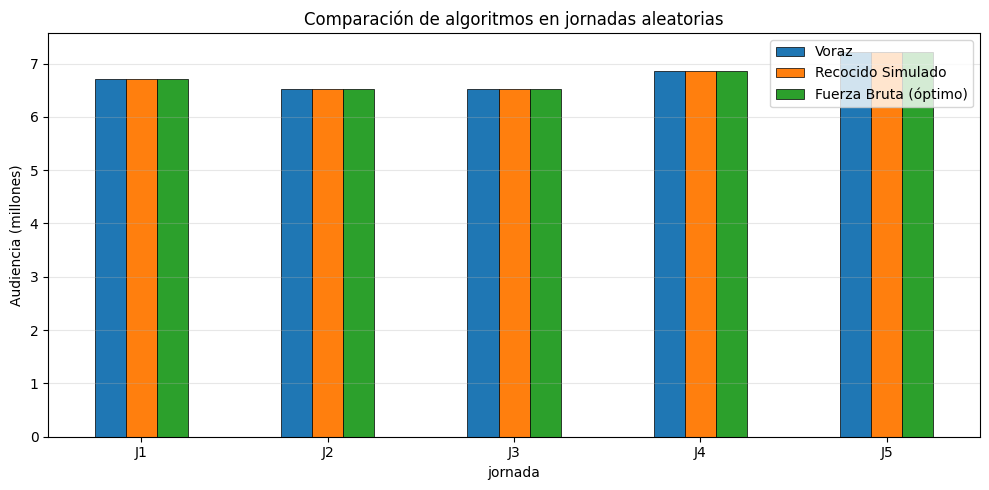


Gap de optimalidad (diferencia vs fuerza bruta):
  J1: Voraz gap=0.0%, SA gap=0.0%
  J2: Voraz gap=0.0%, SA gap=0.0%
  J3: Voraz gap=0.0%, SA gap=0.0%
  J4: Voraz gap=0.0%, SA gap=0.0%
  J5: Voraz gap=0.0%, SA gap=0.0%


In [14]:
# Gráfico comparativo de jornadas aleatorias
df_res = pd.DataFrame(resultados_aleatorios).set_index('jornada')

ax = df_res.plot(kind='bar', figsize=(10, 5), edgecolor='black', linewidth=0.5)
ax.set_ylabel('Audiencia (millones)')
ax.set_title('Comparación de algoritmos en jornadas aleatorias')
ax.legend(['Voraz', 'Recocido Simulado', 'Fuerza Bruta (óptimo)'])
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Calcular gap de optimalidad
print("\nGap de optimalidad (diferencia vs fuerza bruta):")
for _, row in df_res.iterrows():
    gap_v = (row['fuerza_bruta'] - row['voraz']) / row['fuerza_bruta'] * 100
    gap_sa = (row['fuerza_bruta'] - row['recocido_simulado']) / row['fuerza_bruta'] * 100
    print(f"  {_}: Voraz gap={gap_v:.1f}%, SA gap={gap_sa:.1f}%")

---
## 9. Referencias

1. **Kirkpatrick, S., Gelatt, C. D., & Vecchi, M. P.** (1983). *Optimization by Simulated Annealing*. Science, 220(4598), 671-680.

2. **Cormen, T. H., Leiserson, C. E., Rivest, R. L., & Stein, C.** (2009). *Introduction to Algorithms* (3rd ed.). MIT Press.

3. **Russell, S. & Norvig, P.** (2021). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson.

4. **Drexl, A., & Knust, S.** (2007). *Sports league scheduling: Graph- and resource-based models*. Omega, 35(5), 465–471.

5. **Python Documentation**: `itertools`, `numpy`, `matplotlib`. https://docs.python.org/3/

---
## 10. Líneas de trabajo futuro

1. **Coincidencia de horarios**: Permitir que varios partidos se asignen a la misma franja horaria, con la penalización por coincidencia. Esto expande el espacio de $n!$ a $n^n$ y requiere metaheurísticas.

2. **Múltiples jornadas**: Optimizar la planificación de toda la temporada (38 jornadas), considerando restricciones como que cada equipo no juegue siempre a la misma hora.

3. **Audiencias reales**: Integrar datos históricos de audiencia de plataformas como Movistar+ para mejorar las estimaciones de audiencia base.

4. **Restricciones adicionales**:
   - Equipos de la misma ciudad no juegan el mismo día
   - Horarios preferentes por contrato televisivo
   - Seguridad y disponibilidad policial

5. **Algoritmos genéticos y programación entera**: Formular como ILP con restricciones lineales, o usar GA con operadores de cruce especializados para permutaciones.